# From a connectome to sampled motif counts
---
How the paper generates its null networks, on one subcircuit, end to end:

1. the neurons of one cell type, with their positions and connections (the NMC `L5_MC` subcircuit, bundled with the package) →
2. a geometric model of connection probability fitted to them →
3. the probability of every possible connection →
4. random networks drawn from those probabilities →
5. their triplet-motif counts.

At the end, the result is checked against the counts the paper reports (shipped with the package as `load_motifs()`).

In [1]:
import numpy as np
import pandas as pd

from neuromotifs import load_nmc, GeometricModel, motif_counts, load_motifs
from neuromotifs.sampling import sample_motif_counts, motif_counts_row, MOTIF_COLUMNS

## The connectome
One cell type of the Blue Brain microcircuit: where each neuron sits and which neurons it connects to. `L5_MC` is small enough to be bundled, so this notebook runs offline (any other cell type needs the NMC portal file: `load_nmc(mtype, path=...)`).

Positions are in micrometres with `z` the cortical vertical axis; `A[i, j] == 1` means neuron `i` connects to neuron `j`.

In [2]:
connectome = load_nmc("L5_MC")
print(connectome.source)

print(
    f"{len(connectome.A):,} neurons, {connectome.A.sum():,} connections, p = {connectome.A.mean():.4f}"
)

display(pd.DataFrame(connectome.positions, columns=["x", "y", "z"]).round(0))

bundled extract of cons_locs_pathways_mc2_Column.h5
395 neurons, 891 connections, p = 0.0057


,x,y,z
0,439.0,580.0,766.0
1,171.0,620.0,1190.0
2,377.0,720.0,816.0
3,317.0,418.0,1142.0
4,512.0,528.0,978.0
...,...,...,...
390,488.0,461.0,1221.0
391,228.0,469.0,1203.0
392,224.0,668.0,838.0
393,499.0,674.0,895.0


## Fit a geometric model
The model answers one question: given where two neurons sit, how likely is a connection from one to the other? It is fitted on every ordered pair of the connectome.

How much of the geometry the model sees is its *order*: `er` nothing (a constant), `dd` the distance, `ddz` the distance and whether the target is above or below, `od` the full offset vector, `ld` the offset and the source's position. The default classifier is the paper's (a gradient-boosted ensemble of 500 trees, depth 5; about a minute on this subcircuit).

In [3]:
%%time
model = GeometricModel("dd").fit(connectome.positions, connectome.A)
model.feature_names_

CPU times: user 42.8 s, sys: 473 ms, total: 43.3 s
Wall time: 43.4 s


['offset_rho']

## The probability matrix
For every ordered pair, the fitted model gives the probability of a connection (an `n × n` matrix, zero on the diagonal). Its mean reproduces how sparse the connectome is, and, for this order, it falls with distance in the same way the data do.

In [4]:
P = model.predict_proba(connectome.positions)
off_diagonal = ~np.eye(len(P), dtype=bool)
print(
    f"P: {P.shape}, mean {P[off_diagonal].mean():.4f} (connectome: {connectome.A[off_diagonal].mean():.4f})"
)

P: (395, 395), mean 0.0057 (connectome: 0.0057)


<Axes: title={'center': 'dd model vs. data'}, xlabel='intersomatic distance (µm)', ylabel='connection probability'>

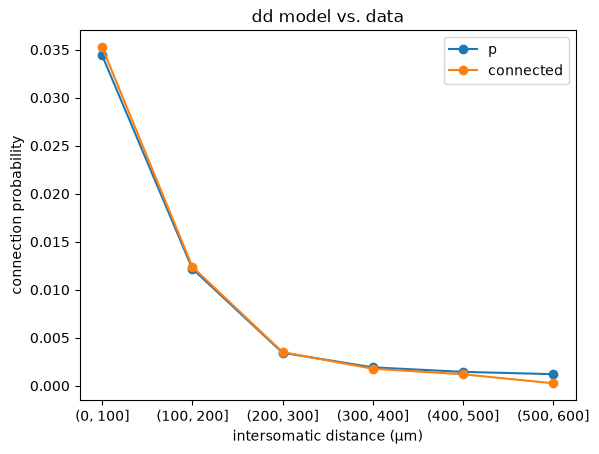

In [5]:
distance = np.linalg.norm(
    connectome.positions[:, None] - connectome.positions[None, :], axis=2
)
display(
    pd.DataFrame(
        {
            "distance": distance[off_diagonal],
            "p": P[off_diagonal],
            "connected": connectome.A[off_diagonal],
        }
    )
    .groupby(pd.cut(distance[off_diagonal], np.arange(0, 700, 100)), observed=True)[
        ["p", "connected"]
    ]
    .mean()
    .plot(
        marker="o",
        xlabel="intersomatic distance (µm)",
        ylabel="connection probability",
        title="dd model vs. data",
    )
)

## Sample networks and count their motifs
Each random network keeps or drops every possible connection independently, with its probability. The result of interest is not the network but its *motif profile*: how many times each of the 13 connected three-neuron patterns occurs.

Start with the connectome itself: its own motif counts are the reference the models are judged against (the `bb` row, for Blue Brain).

In [6]:
motifs = pd.DataFrame([motif_counts_row(connectome.A, model="bb", celltype="L5_MC")])
motifs

,motif_1,motif_2,motif_3,motif_4,motif_5,motif_6,motif_7,motif_8,motif_9,motif_10,motif_11,motif_12,motif_13,nodes,edges,reciprocal_edges,model,celltype
0,1857,1429,1336,88,47,59,7,1,1,1,0,0,0,395,891,10,bb,L5_MC


Now three random networks from the model. Each one is drawn from its own seed, recorded in the table, so any network can be regenerated later (one row per network, in the same table layout as the paper's data: the 13 motif counts, the network size, the seed).

In [7]:
motifs_control = sample_motif_counts(
    P, n_samples=3, base_seed=1300, model="dd", celltype="L5_MC"
)
motifs_control

,motif_1,motif_2,motif_3,motif_4,motif_5,motif_6,motif_7,motif_8,motif_9,motif_10,motif_11,motif_12,motif_13,nodes,edges,reciprocal_edges,seed,model,celltype
0,2160,1022,1050,27,40,41,8,0,0,0,0,0,0,395,912,8,1300,dd,L5_MC
1,2201,1110,1048,26,40,24,10,0,0,1,0,0,0,395,906,7,1301,dd,L5_MC
2,1807,846,925,14,89,75,8,1,1,0,1,0,0,395,876,19,1302,dd,L5_MC


## Does it match the paper?
The paper's counts for this subcircuit come with the package (`load_motifs()`): the connectome's own row and 1,000 random networks per model order, drawn in 2019 from the same kind of model. Two checks:

1. our connectome row must equal the paper's, count for count;
2. our three random networks should look like draws from the paper's 1,000 (for each motif, the distance from the paper's mean in units of its standard deviation, the z-score, should be of order one).

In [8]:
motifs_paper = load_motifs().query("celltype == 'L5_MC'")
display(motifs_paper.query("model in ['bb', 'dd']"))

paper_bb = motifs_paper.query("model == 'bb'")[MOTIF_COLUMNS].iloc[0]
assert (motifs[MOTIF_COLUMNS].iloc[0] == paper_bb).all()
print("computed bb counts identical to motifs.csv.gz.")

paper_dd = motifs_paper.query("model == 'dd'")[MOTIF_COLUMNS]
assert motifs_control[MOTIF_COLUMNS].equals(paper_dd.iloc[:3].reset_index(drop=True))
print("computed sample counts identical to motifs.csv.gz.")

,motif_1,motif_2,motif_3,motif_4,motif_5,motif_6,motif_7,motif_8,motif_9,motif_10,...,reciprocal_edges,seed,celltype,hcid,structural,regressor,regressor_learning_rate,regressor_max_depth,regressor_n_estimators,regressor_random_state
0,1857,1429,1336,88,47,59,7,1,1,1,...,10,NaN,L5_MC,2,False,NaN,NaN,NaN,NaN,NaN
1,2160,1022,1050,27,40,41,8,0,0,0,...,8,1300.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
2,2201,1110,1048,26,40,24,10,0,0,1,...,7,1301.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
3,1807,846,925,14,89,75,8,1,1,0,...,19,1302.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
4,1787,962,918,10,32,45,4,1,0,0,...,9,1303.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,2066,991,989,18,39,39,4,1,0,0,...,8,10395.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
997,2044,1028,974,25,80,66,4,2,2,1,...,15,10396.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
998,1905,961,920,18,51,62,5,1,0,0,...,13,10397.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0
999,1879,974,912,18,54,58,9,1,0,0,...,13,10398.0,L5_MC,2,False,GradientBoostingClassifier,0.01,5.0,500.0,1234.0


computed bb counts identical to motifs.csv.gz.
computed sample counts identical to motifs.csv.gz.
